# 📘 Chapter 07 — Model Prediction & Evaluation 

## 🎯 Objectives  
In this chapter, we will load the optimized Random Forest model, generate predictions on the test set, evaluate model performance (MAE, RMSE, R²), visualize prediction quality, analyze residuals, and optionally export results.

### 🧩 Step 01 — Load Final Model & Test Set  

Load final rf model and access the processed train/test split.

In [12]:
import joblib
import pandas as pd

from src.config import MODEL_DIR
from src.utils.emoji_log import success, data, info

from src.modeling.train_baseline import (
    split_train_test,
    load_cleaned_data,
    build_features,
)
from src.features.feature_engineering import (
    clip_pollutants,
    add_rolling_features,
    handle_outliers_iqr,
    log_transform_features,
    scale_features,
)

In [5]:
# === 1. Data Preparation ===
df = load_cleaned_data("Taiwan")

# === 2. Feature Engineering Pipeline ===
df_clip = clip_pollutants(df.copy())
df_rolling = add_rolling_features(df_clip)
df_iqr = handle_outliers_iqr(df_rolling)
df_log = log_transform_features(df_iqr)

# === 3. Feature construction ===
X, y = build_features(df_log)

# === 4. Scaling (same method as model training) ===
X_scaled = scale_features(X, save_=False)

# === 5. Train-test split ===
data_split = split_train_test(X_scaled, y)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

📂 Loading CSV: C:\Users\dinni\OneDrive\桌面\air_pollution\data\processed\Taiwan.csv
✅ Read CSV successfully! Shape: (5823862, 25)
✅ The pollutants limit has been set.
⚠️ Skipping nox due to NO + NO2 already exist.
✅ Rolling features added.
✅ IQR has been set.
✅ Pollutants skewes has been smoothed.
💬 Features shape: (5823862, 32), Target shape: (5823862,)
✅ Numerical features have been standardized. (32 columns scaled)
✅ Data successfully split! Train: (4659089, 32), Test: (1164773, 32)


In [3]:
# Load rf_final model
MODEL_PATH = MODEL_DIR / "rf_final_model_20251115_1215.pkl"
rf_model = joblib.load(MODEL_PATH)
success("Final model loaded successfully.")

✅ Final model loaded successfully.


### 🧮 Step 02 — Predict AQI on Test Data

Use the final Random Forest model to generate predictions.

In [7]:
y_pred_full = rf_model.predict(X_test)

### 📊 Step 03 — Evaluate Model Performance

Compute MAE, RMSE, and R² to understand model quality.

In [10]:
from src.modeling.evaluate_model import evaluate_and_save

In [11]:
evaluate_and_save(rf_model, X_test, y_test, "rf_model_final")

💬 rf_model_final Results: {'MAE': 6.377279284206558, 'RMSE': 9.526542415615609, 'R2': 0.8977136582151072}
💾 rf_model_final model saved at C:\Users\dinni\OneDrive\桌面\air_pollution\models\rf_model_final_20251115_2110.pkl
💾 Metrics saved at C:\Users\dinni\OneDrive\桌面\air_pollution\models\rf_model_final_metrics_20251115_2110.json


{'MAE': 6.377279284206558,
 'RMSE': 9.526542415615609,
 'R2': 0.8977136582151072,
 'timestamp': '20251115_2110'}

### 🎨 Step 04 — Predicted vs Actual Visualization 

In this step, we visualize the relationship between the model’s AQI predictions and the actual AQI values.
Since our test dataset contains over a million records, we will use a sample of **5,000** rows for visualization to prevent the plots from becoming overly dense ("a solid block of points") and to maintain efficient rendering performance.

#### 📌 04-1 Scatter Plot — Predicted vs Actual
This scatter plot shows how close the predicted AQI values are to the actual AQI.  
Points aligned near the diagonal line indicate better predictions.

In [13]:
import matplotlib.pyplot as plt

In [ ]:
# narrow down the amount of samples for visaulization
X_sample = X_test.sample(5000, random_state=42)
y_sample_actual = y_test.loc[X_sample.index] # pandas.Series
y_sample_pred = rf_model.predict(X_sample) # np.ndarray

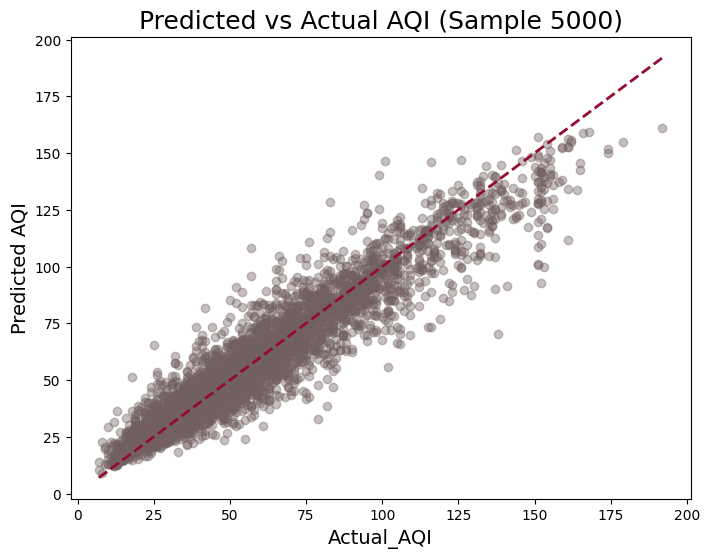

In [ ]:
plot_df = pd.DataFrame({"actual": y_sample_actual, "predicted": y_sample_pred})

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["actual"], plot_df["predicted"], alpha=0.4, color="#726060")
# y=x
plt.plot(
    [plot_df["actual"].min(), plot_df["actual"].max()],
    [plot_df["actual"].min(), plot_df["actual"].max()],
    linestyle="--",
    linewidth=2,
    color="#940B2E"
)
plt.title("Predicted vs Actual AQI (Sample 5000)", fontsize=18)
plt.xlabel("Actual_AQI", fontsize=14)
plt.ylabel("Predicted AQI", fontsize=14)
plt.show()

#### 📌 04-2 Line Plot — First 300 Samples Comparison

This line plot compares the first 300 actual vs predicted AQI values to visualize local fluctuations and trends.

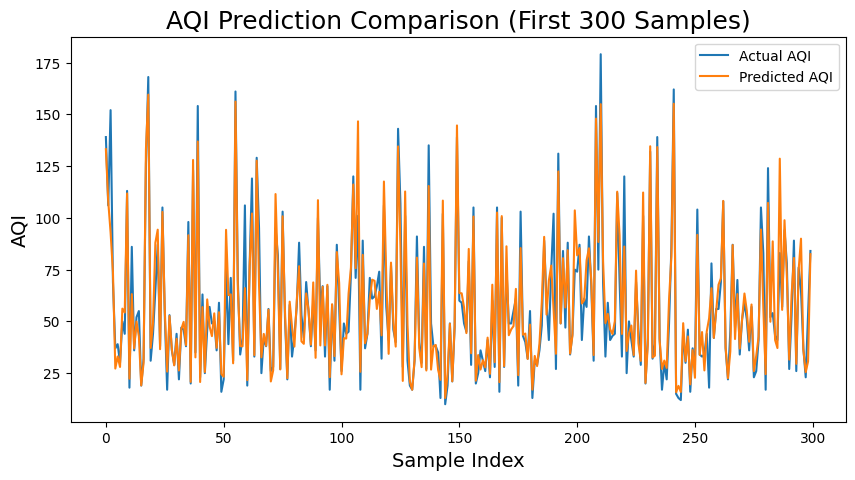

In [36]:
plt.figure(figsize=(10,5))
plt.plot(y_sample_actual.values[:300], label="Actual AQI")
plt.plot(y_sample_pred[:300], label="Predicted AQI")
plt.title("AQI Prediction Comparison (First 300 Samples)", fontsize=18)
plt.xlabel("Sample Index", fontsize=14)
plt.ylabel("AQI", fontsize=14)
plt.legend()
plt.show()

### 📝 Step 04 Summary — Visualization Insights  
In this step, we compared the model’s predictions against the actual AQI values using two visualization approaches:

1. **Scatter Plot (Sample 5000)**  
   - Points are closely aligned along the diagonal reference line, indicating that the model generally predicts AQI accurately.  
   - The spread increases slightly as AQI levels increase, suggesting a bit more variance at higher pollution values — a common characteristic in environmental data.  
   - Overall, the pattern shows strong correlation and low bias.

2. **Line Plot (First 300 Samples)**  
   - The predicted AQI curve closely follows the actual AQI curve, capturing local fluctuations and peaks effectively.  
   - The model is responsive to sharp changes and does not lag behind the actual measurements.  
   - This confirms that the model performs well not only in overall accuracy but also in short-term variability.

**Takeaway:**  
Both visualizations demonstrate that the Random Forest model produces stable and reliable predictions across a wide range of AQI levels.


### 🩺 Step 05 — Residual Analysis  

In this step, we analyze the model’s prediction errors (residuals) to evaluate whether the Random Forest model exhibits systematic bias or instability across different AQI levels.  
Residual analysis helps us understand how accurately the model captures underlying patterns and whether any structural issues remain in the predictions.

Since the test dataset contains over a million records, we will again use a **sample of 5,000 rows** for visualization to ensure clear, readable plots and efficient rendering performance.

In [37]:
res_df = pd.DataFrame({
    "actual": y_sample_actual,
    "predicted": y_sample_pred
    })

res_df["residual"] = res_df["actual"] - res_df["predicted"]
res_df.head()

,actual,predicted,residual
5719042,139.0,133.145096,5.854904
1211696,106.0,107.947483,-1.947483
5183762,152.0,92.921325,59.078675
4842354,69.0,73.847785,-4.847785
688480,37.0,27.223178,9.776822
